# **StockGuard_for_youtube — Modeling**

전처리 산출물을 입력으로 3개 가설 검증.

**도메인 근거**: KCMI 이슈보고서 21-05(유튜브 주식채널의 정보효과와 위험요인), 금융위 보도자료 2024.8.14(유사투자자문 불건전영업 규율), 금감원 불법금융신고센터(fine.fss.or.kr).

### **0. 환경 설정 & 데이터 load**

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

plt.rcParams['font.family'] = 'NanumGothic' # 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

P = Path('../data/processed')
cf  = pd.read_csv(P / 'channel_features.csv')                 # 채널 feature 매트릭스 (ML 입력)
lab = pd.read_csv(P / 'channel_labels.csv')                   # search_query — 평가·사전 참고용(누수 차단)
chc = pd.read_csv(P / 'channels_clean.csv')                   # 라벨 생성용 채널 description
vdc = pd.read_csv(P / 'videos_clean.csv', usecols=['channel_id', 'title', 'description'])
print(f'channel_features {cf.shape} | labels {lab.shape} | channels {chc.shape} | videos {vdc.shape}')

channel_features (2214, 46) | labels (2214, 3) | channels (2214, 20) | videos (32972, 3)


### **1. 분석 프레임 — 데이터 분석가 관점**

여기서는 **차단 의사결정 문제**. 최종 산출물은 채널을 가려낸 **두 리스트 — 차단 리스트·의심 리스트**(6장에서 CSV로 출력).

**오류 비용의 비대칭**
- false positive = 정상 채널을 막음 → 사용자 신뢰 훼손 + 채널 운영자 피해(법적 리스크). 비용 큼.
- false negative = 리딩방 통과 → 시청자 피해 지속. 비용 있으나 의심 리스트·신고 등 보완 수단 존재.

→ **차단 리스트는 precision 우선, 의심 리스트는 recall 허용**. 단일 정확도 수치로 판단하지 않고 threshold 별로 따로 평가.

**모집단과 일반화 한계**: 분석 대상 = 30개 주식 검색어로 수집된 채널 2,214개. 경제 유튜브 전체가 아니므로 결론도 이 범위 안에서만 유효.

**정답 누수 방지 규칙** — 누수는 정답 라벨이 학습 데이터에 섞여 들어가, 모델이 실제 패턴 대신 정답을 외워버리는 문제다. 아래 두 경로를 막는다.
- `search_query` = 수집 키워드 → feature 금지, 평가·사전 참고용으로만.
- 금융위 규제어 = 라벨(y) 근거 → feature로 쓰면 regex 재학습(순환). 텍스트 의미축(`desc_pca_*`)도 규제어를 간접 포함할 수 있어 본 검증에서 제외, ablation으로만 비교.

**사전 판정기준**

| 가설 | 방법 | 채택 기준 |
|---|---|---|
| H1 리딩방은 규제키워드 없이도 채널 운영 패턴만으로 판별 가능 | 지도학습 분류 (RandomForest, LogisticRegression) | 테스트셋 recall ≥ 0.7 그리고 F1 ≥ 0.6 |
| H2 작전성 채널은 참여·구조 지표 공간에서 별도 군집으로 분리 | 표준화 → PCA → KMeans | 군집–정답 라벨 V-measure ≥ 0.2 |
| H3 의심군의 참여율·시황민감도는 정상군과 다름 | Welch t-test + Mann-Whitney + ANOVA | Welch·Mann-Whitney 모두 p < 0.05 (α 사전 고정) — 실질 크기는 평균차·95% 신뢰구간으로 해석 |

**방법 선택 이유**

H2 군집 평가는 V-measure로 한다. 군집에는 정답 라벨이 없어 silhouette 같은 내부 지표만으로는 "의심과 정상이 실제로 갈렸는지"를 답하지 못한다. 그래서 외부 평가 지표를 쓴다 — 각 군집이 한 클래스만 담는지 보는 동질성, 한 클래스가 한 군집에 모이는지 보는 완전성, 그 둘을 합친 V-measure(0~1)다. 어느 군집이 의심인지 이름을 모르니 accuracy는 못 쓰지만, V-measure는 분할 구조만 비교하므로 정답 라벨과의 일치를 그대로 잴 수 있다. silhouette은 군집이 또렷한지 점검하는 보조로만 둔다. 기준 0.2는 우연 수준(0)보다 확실히 위라는 약한 문턱이다.

H3는 두 군의 차이를 평균과 분포 양쪽에서 본다. 의심군 424개와 정상군 1,428개는 표본 크기와 분산이 크게 달라 등분산을 가정하는 보통 t-test가 맞지 않으므로, 그 가정을 푼 Welch t-test(`equal_var=False`)로 평균차를 검정한다. 다만 참여율 분포가 전처리 EDA에서 오른쪽으로 크게 치우쳐 정규성을 믿기 어려워, 순위로 비교하는 비모수 검정 Mann-Whitney를 함께 돌리고 두 검정이 일치할 때만 차이를 인정한다. 치우친 분포에서 t-test만 유의해지는 거짓 신호를 거르려는 것이다.

차이가 유의하다는 것과 차이가 크다는 것은 별개의 문제다. 평균차의 95% 신뢰구간(구간추정), 두 군의 평균·중앙값 비교, 그리고 boxplot으로 크기를 가늠한다. 그래서 H3는 Welch와 Mann-Whitney가 모두 p<0.05로 일치할 때 비로소 유의하다고 보고, 그렇게 확인된 차이에 한해 신뢰구간과 boxplot으로 실제 크기가 얼마나 되는지 따져본다.

### **2. 지도학습 H1의 정답 데이터 만들기 — 규제어 기반(공식 근거)**

H1 분류 모델을 학습시키려면 "이 채널이 의심인지 정상인지"를 적어 둔 정답 데이터가 필요하다. 정답을 사람이 하나하나 달 수 없으니, 규제기관이 공식 문서에서 콕 집은 표현(규제어)이 채널 글에 나오는지로 정답을 매긴다. 규제어는 **정답을 매기는 근거**지 모델에 넣는 feature가 아니다.

| 규제어 | 출처 |
|---|---|
| 수익률·원금 보장, 손실 보전 | 금융위 금지광고(2024.8.14 보도자료) |
| VIP 방·종목·회원 | 금융위 금지광고(VIP 종목) |
| 리딩방, 무료 리딩 | 금융위·금감원 규제 대상 |
| 종목 추천, 추천주 | 금감원 불법유형(종목추천 대가 수취) |
| 자동매매 | 금감원 불법유형(자동매매프로그램 판매) |

**정답 매기는 규칙**: 채널 description + 그 채널 영상 제목·설명에서 규제어를 센다.
- 서로 다른 규제어 2종 이상 **또는** 총 5회 이상(도배) → 의심(`suspect`)
- 0회 → 정상(`normal`)
- 그 외(단일 유형 1~4회) → 회색지대, 학습에서 제외 — 뉴스·사기 주의 환기 채널이 1~2회 언급으로 오염되는 것 방지

임계값은 아래 민감도 표를 보고 정했다. 표의 핵심은 A그룹(리딩방을 노린 검색어로 모은 채널)이 B그룹(정상 주식 검색어로 모은 채널)보다 의심으로 얼마나 더 많이 잡히느냐다(`A/B 배율` 칸). 이 차이가 클수록 정답이 검색 의도대로 잘 갈렸다는 뜻이다.

규제어를 1종·1회까지 느슨하게 풀면 의심으로 잡히는 채널이 786개로 늘지만 회색지대가 통째로 사라지고, A가 B보다 의심으로 잡히는 정도도 3.7배까지 떨어진다 — 뉴스나 주의 환기 채널이 규제어를 한 번 언급한 것만으로 의심에 섞여, 검색어로 기대했던 구분이 흐려지기 때문이다. 반대로 2종·7회나 3종·5회로 더 빡빡하게 잡으면 그 차이는 5.2~5.5배로 조금 더 벌어지지만, 학습에 쓸 의심 채널이 377~379개로 줄고 회색지대가 400개 넘게 불어난다.

`2종 또는 5회`는 이 차이가 이미 5.09배로 충분히 벌어지면서 학습에 쓸 의심 채널 424개도 함께 확보되는 지점이다 — 더 느슨하게 잡으면 구분이 흐려지고, 더 빡빡하게 잡으면 학습 데이터가 모자라는 그 사이 균형점이다. 도메인으로 봐도 금융위·금감원이 단속하는 건 한 번 흘린 말이 아니라 서로 다른 위반을 같이 하거나 같은 표현을 반복해 도배하는 영업 행위라, 2종 이상이나 도배(5회)는 영업성을 가리키고 단일 1~4회는 판단을 보류(회색)하는 것이 맞다.

**정답 데이터 결과**

| 구분 | 채널 수 | 부여 조건 |
|---|---|---|
| 의심(`suspect`) | 424 | 규제어 2종 이상 또는 총 5회 이상 |
| 정상(`normal`) | 1,428 | 규제어 0회 |
| 회색지대(학습 제외) | 362 | 단일 유형 1~4회 |

검색어 그룹별 의심 비율은 A그룹(리딩방 타겟) 34%, C그룹(교차) 11%, B그룹(정상 타겟) 7% 순으로, 검색어로 채널을 모을 때 기대했던 방향과 그대로 맞아떨어진다. `search_query`는 정답을 매길 때 쓰지 않았으니 순환이 아니라 정답이 타당함을 독립적으로 뒷받침하는 방증이다.

**한계**: 리딩방 폭로·주의 환기 채널이 일부 섞일 수 있음 → 회색지대 분리로 완화, 7장 한계에 재명시.

In [2]:
REG = {
    '수익보장': r'수익률?\s*보장|원금\s*보장|손실\s*보전',
    'VIP'    : r'VIP\s*(?:방|반|종목|클럽|멤버|회원)|브이아이피',
    '리딩방' : r'리딩\s*방|주식\s*리딩|무료\s*리딩',
    '종목추천': r'종목\s*추천|추천\s*종목|추천주',
    '자동매매': r'자동\s*매매',
}
vdc['txt'] = vdc['title'].fillna('') + ' ' + vdc['description'].fillna('')
vtext = vdc.groupby('channel_id')['txt'].apply(' '.join)
text = (chc['description'].fillna('') + ' ' + chc['channel_id'].map(vtext).fillna('')).set_axis(chc['channel_id'])

H = pd.DataFrame({k: text.str.count(p, flags=re.I) for k, p in REG.items()})
H['kinds'] = (H[list(REG)] > 0).sum(axis=1)
H['total'] = H[list(REG)].sum(axis=1)

seed = pd.Series('unlabeled', index=H.index)
seed[H['total'] == 0] = 'normal'
seed[(H['kinds'] >= 2) | (H['total'] >= 5)] = 'suspect'

# 검색어 그룹(A=리딩방 타겟 12 / B=정상 타겟 12 / C=교차 6) — 평가·사전 참고용
A = ['주식리딩방','주식종목추천','급등주','수익률보장','오늘의추천주','무료리딩',
     '단타매매','주식자동매매','주식투자방법','테마주','주식대박','VIP종목']
B = ['주식투자','주식시장','경제전망','기업분석','코스피','코스닥',
     '주식시황','재테크','주식공부','애널리스트','ETF투자','미국주식']
grp = lab.set_index('channel_id')['search_query'].map(lambda q: 'A' if q in A else ('B' if q in B else 'C'))

cf['seed'] = cf['channel_id'].map(seed)
cf['q_group'] = cf['channel_id'].map(grp)

print(cf['seed'].value_counts().to_dict())
print('\n검색어 그룹별 정답 라벨 분포(행 비율):')
print(pd.crosstab(cf['q_group'], cf['seed'], normalize='index').round(3))
print('\n의심으로 표시한 채널 상위(규제어 총 매칭순) — 눈 검증:')
top_sus = H.loc[seed == 'suspect'].nlargest(8, 'total')
display(top_sus.join(chc.set_index('channel_id')['title'])[['title', 'kinds', 'total']])

{'normal': 1428, 'suspect': 424, 'unlabeled': 362}

검색어 그룹별 정답 라벨 분포(행 비율):
seed     normal  suspect  unlabeled
q_group                            
A         0.415    0.341      0.244
B         0.841    0.067      0.092
C         0.765    0.106      0.129

의심으로 표시한 채널 상위(규제어 총 매칭순) — 눈 검증:


,title,kinds,total
channel_id,,,
UCPbb_OLIxmqelxxHSIEjJAg,"통통주식TV= (단타,스윙)검색기+자동매매",3,370
UCYslozpPZoYEgPtn18vCucQ,업리치- 비트코인자동매매 No.1,1,156
UCdruNV1JV05WIas8L9zQaiA,주식천국 [소액투자자 전문지원],2,152
UCDOAILOwtCXMAPj2sLuLA1w,40대 아빠의 재테크,2,140
UCYJSLwjCoUEbSsc5mP74Pqw,실크로드자동매매,1,139
UCLaxMxEo0VoRvJ4ZAh4X2cg,FX자동매매 수익재태크,2,138
UCmeKw0rCkr2XRTVXcmrlllw,슈퍼개미주식투자TV,3,122
UC5JYQZwCn8uoxBpAA8yonaw,천만수익-해외선물자동매매프로그램오토로봇,1,122


In [3]:
# 임계 근거: 임계를 바꿔가며 라벨 토대가 흔들리는지 점검 (의심 채널 규모 vs A·B 구분 정도)
def _seed_at(kk, tt):
    s = pd.Series('gray', index=H.index)
    s[H['total'] == 0] = 'normal'
    s[(H['kinds'] >= kk) | (H['total'] >= tt)] = 'suspect'
    return s

_gA = cf.set_index('channel_id')['q_group'].reindex(H.index)
sens = []
for kk, tt in [(1, 1), (2, 3), (2, 5), (2, 7), (3, 5)]:
    s = _seed_at(kk, tt)
    ar = (s[_gA == 'A'] == 'suspect').mean()        # A=리딩방 타겟 검색군의 의심율
    br = (s[_gA == 'B'] == 'suspect').mean()        # B=정상 타겟 검색군의 의심율
    sens.append({'규칙': f'{kk}종 또는 {tt}회', 'suspect': int((s == 'suspect').sum()),
                 '회색지대': int((s == 'gray').sum()), 'A의심율': round(ar, 3),
                 'B의심율': round(br, 3), 'A/B 배율': round(ar / br, 2)})
print("채택='2종 또는 5회' — A가 B보다 의심으로 잡히는 정도가 충분히 벌어지면서 학습 데이터도 확보되는 지점")
display(pd.DataFrame(sens).set_index('규칙'))

채택='2종 또는 5회' — A가 B보다 의심으로 잡히는 정도가 충분히 벌어지면서 학습 데이터도 확보되는 지점


,suspect,회색지대,A의심율,B의심율,A/B 배율
규칙,,,,,
1종 또는 1회,786,0,0.585,0.159,3.67
2종 또는 3회,493,293,0.388,0.082,4.71
2종 또는 5회,424,362,0.341,0.067,5.09
2종 또는 7회,377,409,0.304,0.058,5.21
3종 또는 5회,379,407,0.310,0.056,5.53


### **3. H1 — 지도학습 분류**

> **가설**: 리딩방 의심 채널은 명시적 규제키워드 없이도 채널 운영 패턴(참여율, 업로드 시간대, 댓글 행동, 연락처 형식 플래그 등)으로 판별 가능하다.
- **판정기준**: 테스트셋 recall ≥ 0.7 그리고 F1 ≥ 0.6. 차단 의사결정에서 미탐 비용을 감안하면 의심 채널의 최소 70%는 잡아야 도구로서 의미가 있고(recall), 동시에 검색어 정보만 쓰는 기준 모델(F1 0.56)을 확실히 넘겨야 모델이 값을 한다는 뜻에서 F1 0.6을 하한으로 뒀다.
- **방법 근거**: LogisticRegression, confusion matrix, ROC-AUC, RandomForest 사용. 클래스 불균형 약 3.4:1 → 학습셋에 **SMOTE**로 소수(의심) 클래스를 다수와 같은 수로 합성·증강해 보정한다(테스트셋엔 미적용 — 누수 방지). 다만 SMOTE는 고차원·노이즈에 약해 합성 표본이 잡음을 키울 수 있고, 우리 정답 라벨이 regex 휴리스틱이라 노이즈가 섞였다는 한계를 감안해 해석한다.
- **하이퍼파라미터**: `max_iter=1000`은 넉넉한 상한으로 일단 결정했다. LogisticRegression이 실제로는 23회 만에 수렴해 이 상한에 걸리지 않으며(아래 `n_iter_`), 표준화·feature 수가 바뀌어도 수렴이 끊기지 않도록 여유를 둔 값이다. `n_estimators=300`은 GridSearchCV(cv=5, F1)로 50·100·200·300·500을 비교해 고른 값으로, SMOTE로 균형 잡은 학습셋에서 CV F1이 100 이상부터 0.85~0.86으로 포화하고 그중 300이 가장 높았다(아래 표).
- **feature**: 채널 운영 패턴(행동·구조·형식) 36개. `desc_pca_*`(텍스트 의미축)는 규제어 간접 누수 가능 → 본검증 제외, ablation 비교만. 기준 모델 = A그룹 수집 여부로 의심 판정.
- **분할**: `test_size=0.25` — 학습 1,389개로 패턴을 잡고 테스트 463개(의심 약 106개)로 평가해 소수 클래스가 평가에서 충분한 규모가 되게 했고, `stratify`로 의심:정상 비율을 학습·테스트에 동일하게 유지한다(`random_state=42`로 분할 재현 고정)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix)
from imblearn.over_sampling import SMOTE   # 클래스 불균형 보정 (Data Augmentation)

text_cols = [c for c in cf.columns if c.startswith('desc_pca_')]
drop_cols = ['channel_id', 'title', 'seed', 'q_group'] + text_cols
X_cols = [c for c in cf.columns if c not in drop_cols]
med = cf[X_cols].median(numeric_only=True)   # 결측(댓글 없는 채널 등) = 중앙값 채움

m = cf['seed'] != 'unlabeled'
X = cf.loc[m, X_cols].fillna(med)
y = (cf.loc[m, 'seed'] == 'suspect').astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# SMOTE: 소수(의심) 클래스를 다수와 같은 수로 합성·증강 — 학습셋에만 적용(테스트 누수 방지)
X_res, y_res = SMOTE(random_state=42, k_neighbors=5).fit_resample(X_tr, y_tr)

sc = StandardScaler().fit(X_res)
lr = LogisticRegression(max_iter=1000).fit(sc.transform(X_res), y_res)
rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_res, y_res)

base_pred = (cf.loc[y_te.index, 'q_group'] == 'A').astype(int)   # 기준 모델: 검색어 정보 단독

# ablation: desc_pca 포함 모델
Xa_cols = X_cols + text_cols
meda = cf[Xa_cols].median(numeric_only=True)
Xa = cf.loc[m, Xa_cols].fillna(meda)
Xa_res, ya_res = SMOTE(random_state=42, k_neighbors=5).fit_resample(Xa.loc[X_tr.index], y_tr)
rfa = RandomForestClassifier(n_estimators=300, random_state=42).fit(Xa_res, ya_res)

def metrics(name, y_pred, y_score=None):     # 한 행씩 모아 표로 출력 (print 정렬·잘림 방지)
    return {'모델': name,
            'recall': recall_score(y_te, y_pred), 'precision': precision_score(y_te, y_pred),
            'F1': f1_score(y_te, y_pred),
            'AUC': roc_auc_score(y_te, y_score) if y_score is not None else np.nan}

res = pd.DataFrame([
    metrics('LogReg',        lr.predict(sc.transform(X_te)), lr.predict_proba(sc.transform(X_te))[:, 1]),
    metrics('RandomForest',  rf.predict(X_te),               rf.predict_proba(X_te)[:, 1]),
    metrics('기준 모델(A수집)', base_pred),                                              # 검색어 정보 단독, 점수 없음
    metrics('RF+desc_pca',   rfa.predict(Xa.loc[X_te.index]), rfa.predict_proba(Xa.loc[X_te.index])[:, 1]),
]).set_index('모델').round(3)
display(res)

,recall,precision,F1,AUC
모델,,,,
LogReg,0.547,0.392,0.457,0.722
RandomForest,0.481,0.567,0.520,0.795
기준 모델(A수집),0.717,0.463,0.563,NaN
RF+desc_pca,0.538,0.553,0.545,0.811


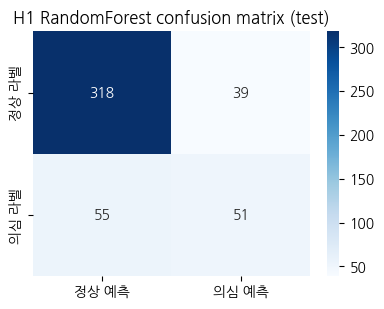

In [5]:
# H1 RandomForest confusion matrix (test) — 그림은 출력과 겹치지 않게 별도 셀
cm_ = confusion_matrix(y_te, rf.predict(X_te))
plt.figure(figsize=(4, 3.2))
sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues',
            xticklabels=['정상 예측', '의심 예측'], yticklabels=['정상 라벨', '의심 라벨'])
plt.title('H1 RandomForest confusion matrix (test)')
plt.tight_layout(); plt.show()

In [6]:
# 하이퍼파라미터 결정 근거 (GridSearchCV·cross validation)
from sklearn.model_selection import GridSearchCV

print(f'LogReg 실제 수렴 반복수 n_iter_ = {int(lr.n_iter_[0])}  (max_iter=1000 상한에 안 걸림)')

gs = GridSearchCV(RandomForestClassifier(random_state=42),
                  {'n_estimators': [50, 100, 200, 300, 500]}, scoring='f1', cv=5).fit(X_res, y_res)
grid = pd.DataFrame({'n_estimators': list(gs.cv_results_['param_n_estimators']),
                     'CV F1 (cv=5)': gs.cv_results_['mean_test_score'].round(4)})
display(grid)
print('best n_estimators =', gs.best_params_['n_estimators'], '— SMOTE 균형 train, 100 이상에서 포화·그중 최고')

LogReg 실제 수렴 반복수 n_iter_ = 23  (max_iter=1000 상한에 안 걸림)


,n_estimators,CV F1 (cv=5)
0,50,0.8473
1,100,0.8511
2,200,0.8537
3,300,0.8590
4,500,0.8567


best n_estimators = 300 — SMOTE 균형 train, 100 이상에서 포화·그중 최고


precision ≥ 0.7: threshold=0.77  recall=0.104
precision ≥ 0.9: threshold=0.92  recall=0.019


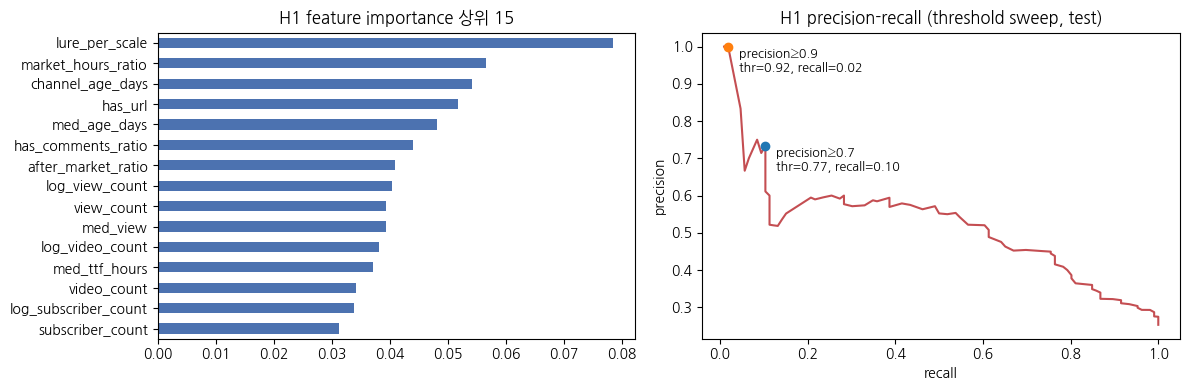

In [7]:
score_te = rf.predict_proba(X_te)[:, 1]
# PR 곡선을 기본 지표(precision_score·recall_score)로 threshold마다 직접 계산
thr_grid = np.round(np.arange(0.05, 0.99, 0.01), 2)
prec = np.array([precision_score(y_te, (score_te >= t).astype(int), zero_division=0) for t in thr_grid])
rec  = np.array([recall_score(y_te,  (score_te >= t).astype(int)) for t in thr_grid])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
imp = pd.Series(rf.feature_importances_, index=X_cols).sort_values().tail(15)
imp.plot(kind='barh', ax=ax[0], color='#4c72b0')
ax[0].set_title('H1 feature importance 상위 15')

ax[1].plot(rec, prec, color='#c44e52')
for pt in [0.7, 0.9]:                       # 리스트 운영점: 의심 리스트(0.7) / 차단 리스트(0.9)
    ok = np.where(prec >= pt)[0]            # 목표 precision을 만족하는 threshold 중 가장 낮은 것(= 최대 recall)
    if len(ok):
        i = ok[0]
        ax[1].scatter(rec[i], prec[i], zorder=3)
        ax[1].annotate(f'precision≥{pt}\nthr={thr_grid[i]:.2f}, recall={rec[i]:.2f}',
                       (rec[i], prec[i]), textcoords='offset points', xytext=(8, -18), fontsize=9)
        print(f'precision ≥ {pt}: threshold={thr_grid[i]:.2f}  recall={rec[i]:.3f}')
ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision'); ax[1].set_title('H1 precision-recall (threshold sweep, test)')
plt.tight_layout(); plt.show()

In [8]:
# regex가 못 보는 회피형 후보: 회색지대(규제어 1~4회 단일 유형) 중 모델 점수 상위
um = cf['seed'] == 'unlabeled'
cf.loc[um, 'rf_score'] = rf.predict_proba(cf.loc[um, X_cols].fillna(med))[:, 1]
display(cf.loc[um].nlargest(8, 'rf_score')[['title', 'rf_score']])

,title,rf_score
1453,주식가치 판단가,0.990000
1418,주식가치 평론가,0.983333
1460,김용진,0.983333
2058,경제흐름 투자전문,0.973333
1488,시장읽기,0.966667
679,투자입문 채널,0.933333
1617,경제공부 주식채널,0.930000
563,1조 자동매매,0.906667


**H1 판정 = 기각.** RandomForest 테스트셋 recall 0.48, F1 0.52 — 사전 기준(recall ≥ 0.7, F1 ≥ 0.6) 미달. 기준 모델(A그룹 수집 여부 단독, recall 0.72·F1 0.56)조차 못 넘음 → 규제어 없이 채널 운영 패턴만으로 규제어 정답 라벨을 재현하기엔 부족. ablation(desc_pca 포함)은 AUC 0.795→0.811(+0.016)로 텍스트 의미축이 약간 보태지만 판정을 뒤집을 정도는 아님.

**그래도 남는 것**
- AUC 0.80 = 이진 분류기로는 약해도 **순위(의심 점수) 능력은 유효**. 차단/통과 2분법 대신 점수 기반 다층 대응으로 용도 전환.
- precision-recall 운영점: precision ≥ 0.9에서 threshold 0.92·recall 0.02 — "확실한 것만 차단"층이지만 SMOTE로 확률이 위로 밀려 포착이 매우 적다. precision ≥ 0.7에서 threshold 0.77·recall 0.10 — 경고층. 고정밀 구간에서 recall이 낮다는 것 자체가 "단일 점수로 많이 차단하면 오차단이 폭증한다"는 것.
- 회피형 탐지 가치: 규제어 회색지대 채널 중 점수 0.9 이상 다수("주식가치 판단가", "주식가치 평론가" 등 전형적 봇 작명 패턴) — **regex 단독으로는 안 잡히는 후보를 모델이 제시** = ML이 키워드 필터를 넘어서는 지점.
- 상위 feature는 외부유도·시황민감도·채널/영상 나이·연락처(`lure_per_scale`·`market_hours_ratio`·`channel_age_days`·`has_url`) 계열 → 유도·신생·시황추종 구조 신호가 판별 축. 단 정답 라벨 noise(휴리스틱)가 성능 상한을 누르고 있을 가능성 있음

### **4. H2 — 비지도 PCA + 군집**

> **가설**: 작전성 채널은 참여·구조 지표 공간에서 별도 군집으로 분리된다.
- **판정기준**: 군집–정답 라벨 V-measure ≥ 0.2. 무작위로 군집을 매겨도 V-measure는 ≈0이 나오므로(아래 null 확인), 0.2는 단지 잡음을 넘기는 수준이 아니라 '실제로 의심·정상이 갈렸다'고 부를 만한 약한 일치 기준으로 둔 값이다(완전 분리 1.0은 탐색 단계에서 비현실적).
- **방법 근거**: 표준화 → PCA → KMeans, k는 silhouette 최대값으로 선택, 외부평가는 동질성·완전성·V-measure. PCA는 10축으로 축소. 정답 라벨은 군집 형성에 미사용 — 사후 평가에만.
- **하이퍼파라미터**: PCA `n_components=10`은 누적 설명분산이 10축에서 약 65%이고 이후 축당 기여가 완만해지는 지점이라, 차원을 작게 유지하면서 정보를 적당히 남기려고 골랐다. KMeans `k`는 silhouette이 최대인 값으로 자동 선택, `n_init=10`은 초기 중심 무작위성에 대비한 반복 횟수다.
- **모델 선택**: KMeans·DBSCAN 중 KMeans를 썼다 — 표준화한 연속 feature 공간을 k 지정으로 나눠 silhouette·elbow·V-measure와 바로 호환된다. DBSCAN은 밀도 기반이라 36차원 표준화 공간에서 `eps`에 민감하고 군집 수가 통제되지 않아 정답 라벨 대조에 부적합하다. `k`는 silhouette 최대(k=5)와 elbow(inertia 꺾임이 4~5에서 완만)가 같은 지점을 가리켜 5로 확정했다.

PCA 누적 설명분산 — 5축 0.465 / 10축 0.652 / 15축 0.783 / 20축 0.877 (n_components=10 채택)


silhouette: {2: 0.242, 3: 0.242, 4: 0.255, 5: 0.256, 6: 0.243, 7: 0.218, 8: 0.236} → 최대 k = 5
inertia(elbow): {2: 42266, 3: 37514, 4: 33315, 5: 30189, 6: 27903, 7: 26097, 8: 24350}


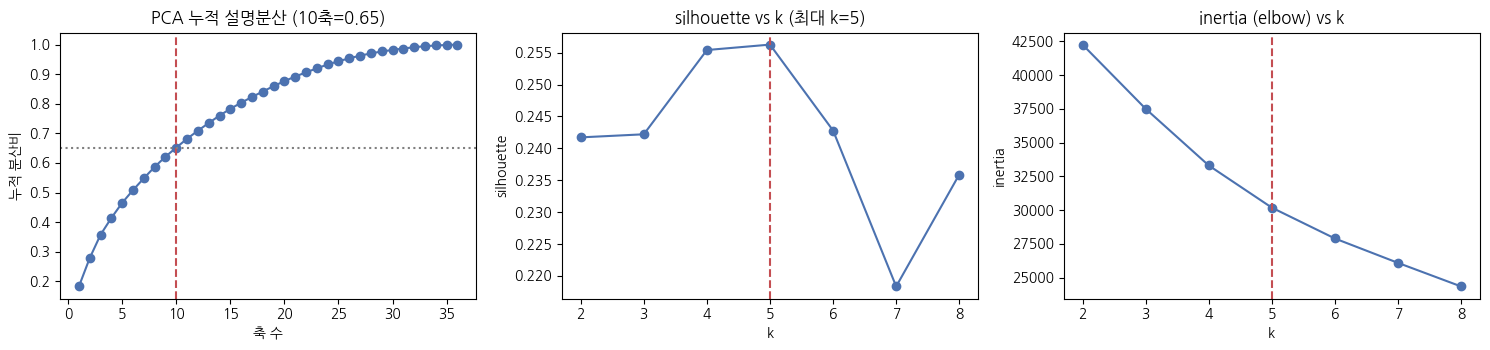

V-measure = 0.031 (기준 0.2) | 동질성 0.045  완전성 0.024 | 전체 의심 비율 0.229


무작위 군집 V-measure ≈ 0.0010 (95%상한 0.0022) — 실제 0.031는 잡음 위지만 0.2 미달


,n,suspect_rate,의심 채널 몰림 지수
cluster,,,
0,853,0.152,0.67
1,819,0.264,1.15
2,2,0.000,0.00
3,41,0.195,0.85
4,137,0.511,2.23


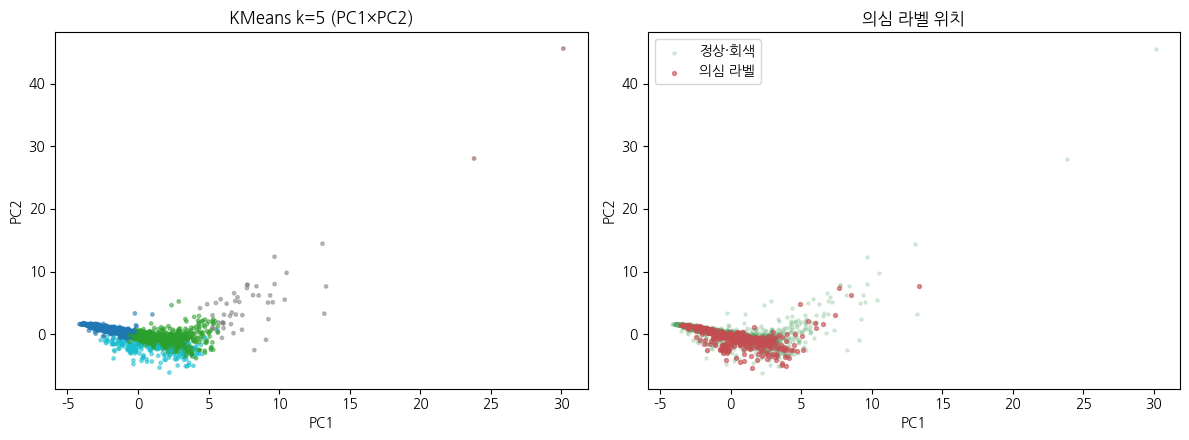

In [9]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, v_measure_score, homogeneity_score, completeness_score

Z = StandardScaler().fit_transform(cf[X_cols].fillna(med))
pca = PCA(n_components=10, random_state=42)
Zp = pca.fit_transform(Z)
_cum = np.cumsum(PCA(random_state=42).fit(Z).explained_variance_ratio_)   # 축 개수 근거: 누적 설명분산
print('PCA 누적 설명분산 — 5축 %.3f / 10축 %.3f / 15축 %.3f / 20축 %.3f (n_components=10 채택)'
      % (_cum[4], _cum[9], _cum[14], _cum[19]))

sils, inert = {}, {}                                      # silhouette + elbow(inertia) 교차로 k 결정
for k in range(2, 9):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Zp)
    sils[k] = silhouette_score(Zp, km_k.labels_); inert[k] = km_k.inertia_
best_k = max(sils, key=sils.get)
print('silhouette:', {k: round(v, 3) for k, v in sils.items()}, '→ 최대 k =', best_k)
print('inertia(elbow):', {k: round(v) for k, v in inert.items()})

# 하이퍼파라미터 결정 근거 시각화 (scree·silhouette·elbow)
fig, dx = plt.subplots(1, 3, figsize=(15, 3.6))
dx[0].plot(range(1, len(_cum) + 1), _cum, marker='o', color='#4c72b0')
dx[0].axvline(10, ls='--', color='#c44e52'); dx[0].axhline(_cum[9], ls=':', color='gray')
dx[0].set_title('PCA 누적 설명분산 (10축=%.2f)' % _cum[9]); dx[0].set_xlabel('축 수'); dx[0].set_ylabel('누적 분산비')
ks = list(sils.keys())
dx[1].plot(ks, [sils[k] for k in ks], marker='o', color='#4c72b0')
dx[1].axvline(best_k, ls='--', color='#c44e52')
dx[1].set_title('silhouette vs k (최대 k=%d)' % best_k); dx[1].set_xlabel('k'); dx[1].set_ylabel('silhouette')
dx[2].plot(ks, [inert[k] for k in ks], marker='o', color='#4c72b0')
dx[2].axvline(best_k, ls='--', color='#c44e52')
dx[2].set_title('inertia (elbow) vs k'); dx[2].set_xlabel('k'); dx[2].set_ylabel('inertia')
plt.tight_layout(); plt.show()

km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Zp)
cf['cluster'] = km.labels_

lm = cf['seed'] != 'unlabeled'
y_true = (cf.loc[lm, 'seed'] == 'suspect').astype(int)
vm   = v_measure_score(y_true, cf.loc[lm, 'cluster'])      # 외부평가: 동질성·완전성 조화평균
homo = homogeneity_score(y_true, cf.loc[lm, 'cluster'])    # 각 군집이 한 클래스만 담나
comp = completeness_score(y_true, cf.loc[lm, 'cluster'])   # 한 클래스가 한 군집에 모이나
base_rate = (cf.loc[lm, 'seed'] == 'suspect').mean()
print(f'V-measure = {vm:.3f} (기준 0.2) | 동질성 {homo:.3f}  완전성 {comp:.3f} | 전체 의심 비율 {base_rate:.3f}')
_rng = np.random.default_rng(42)                          # null: 무작위 군집의 V-measure 기대값 (0.2 문턱 근거)
_null = [v_measure_score(y_true, _rng.integers(0, best_k, size=len(y_true))) for _ in range(200)]
print(f'무작위 군집 V-measure ≈ {np.mean(_null):.4f} (95%상한 {np.quantile(_null, 0.95):.4f}) — 실제 {vm:.3f}는 잡음 위지만 0.2 미달')
tbl = cf[lm].groupby('cluster').agg(n=('seed', 'size'), suspect_rate=('seed', lambda s: (s == 'suspect').mean()))
tbl['의심 채널 몰림 지수'] = (tbl['suspect_rate'] / base_rate).round(2)
display(tbl.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(Zp[:, 0], Zp[:, 1], c=km.labels_, cmap='tab10', s=6, alpha=0.5)
ax[0].set_title(f'KMeans k={best_k} (PC1×PC2)')
sus_m = (cf['seed'] == 'suspect').values
ax[1].scatter(Zp[~sus_m, 0], Zp[~sus_m, 1], s=5, alpha=0.2, color='#55a868', label='정상·회색')
ax[1].scatter(Zp[sus_m, 0], Zp[sus_m, 1], s=8, alpha=0.6, color='#c44e52', label='의심 라벨')
ax[1].set_title('의심 라벨 위치'); ax[1].legend()
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()

**H2 판정 = 기각.** V-measure 0.031 — 기준(0.2)에 크게 미달. 동질성 0.045·완전성 0.024 모두 0에 가까워 군집이 정답 라벨과 거의 무관 = 의심 채널이 별도 군집으로 분리되지 않음. 다만 무작위 군집의 기대 V-measure(≈0.001)와 비교하면 실제 0.031은 그 30배 수준이라 완전한 잡음은 아니다 — 약한 신호는 있으나 의미있는 분리 기준 0.2에는 한참 못 미친다. silhouette도 0.26(k=5) 수준이라 군집 구조 자체가 또렷하지 않음.

**그래도 남는 것**: 한 군집(cluster 4, n=137)에 의심 채널이 51%로 몰려 있음 — 전체 의심 비율 22.9%의 약 2.2배. 완전 분리는 아니지만 의심 채널이 모이는 밀집 지역은 존재. 데이터 분석가 관점에서 군집은 차단 근거가 아니라 **수동 검토 우선순위 큐**로 쓰는 게 맞음(의심이 몰린 군집부터 검토 → 라벨링 비용 절감). "참여·구조 공간만으로는 부족"이라는 기각 자체가 H1의 feature 한계와 일관된 insight.

### **5. H3 — 통계검정**

> **가설**: 의심군의 참여율(`med_comment_rate`)·시황민감도(`market_hours_ratio` = 장중 9~15시 업로드 비율)는 정상군과 다르다.
- **판정기준**: Welch·Mann-Whitney 두 검정 모두 p < 0.05 (α 사전 고정). 실질 크기는 평균차·95% 신뢰구간·boxplot으로 해석.
- **방법 근거**: Welch t-test, Mann-Whitney, ANOVA(f_oneway), 구간추정 사용. 참여율 분포가 오른쪽으로 치우쳐 Welch t-test에 Mann-Whitney 비모수를 병행, 두 검정이 일치할 때만 신뢰. 시황민감도 변수는 KCMI 21-05(개장 전후 방송 패턴, 지수 변동–조회수 상관)에서 채택.
- **검정 선택 근거**: 유의수준 α=0.05와 신뢰수준 95%는 통계 관례를 그대로 따른 고정값이지 데이터를 보고 정한 값이 아니다. 어떤 검정을 쓸지는 데이터 모양이 정한다 — 두 군의 분산비가 1에서 멀어 등분산을 믿기 어려우면 Welch를, 왜도가 6~14로 극심하게 치우친 참여율·첫댓글시간은 정규성을 믿기 어려워 비모수 Mann-Whitney를 병행한다.
- **변수 선택**: 세 변수는 결과를 보고 고른 게 아니라 가설 단계에서 미리 정했다. `market_hours_ratio`(장중 업로드 비율)는 KCMI 21-05가 보고한 개장 전후·장중 집중 방송 패턴의 도메인 변수이며, 장중은 한국거래소 정규장 09:00~15:30(KST)을 기준으로 한다. `med_comment_rate`(영상 댓글률)는 작전성 채널의 시청자 동원·봇 참여를 보는 행동 변수, `med_ttf_hours`(첫 댓글까지 시간)는 업로드 직후 선점 댓글(시딩)을 보는 행동 변수다.

검정 선택 근거 — 분산비가 1에서 멀면 Welch, 왜도가 크면 비모수(MW):
  med_comment_rate: 분산비(의심/정상)=0.05  왜도 의심=6.34/정상=13.98
  market_hours_ratio: 분산비(의심/정상)=0.81  왜도 의심=0.69/정상=0.86
  med_ttf_hours: 분산비(의심/정상)=5.36  왜도 의심=8.74/정상=13.82


,변수,의심 평균,정상 평균,평균차,평균차 95%CI,welch_p,mw_p
0,med_comment_rate,0.0042,0.0074,-0.0032,"[-0.0064, -0.0000]",0.0490,0.7921
1,market_hours_ratio,0.3398,0.3047,0.0352,"[0.0070, 0.0634]",0.0148,0.0004
2,med_ttf_hours,657.4369,213.3642,444.0727,"[-74.5490, 962.6943]",0.0943,0.8975


ANOVA market_hours_ratio (A/B/C): F=10.75  p=2.3e-05  그룹평균=[np.float64(0.3557), np.float64(0.2978), np.float64(0.3027)]
ANOVA med_comment_rate (A/B/C): F=0.41  p=6.6e-01  그룹평균=[np.float64(0.0091), np.float64(0.0071), np.float64(0.0063)]


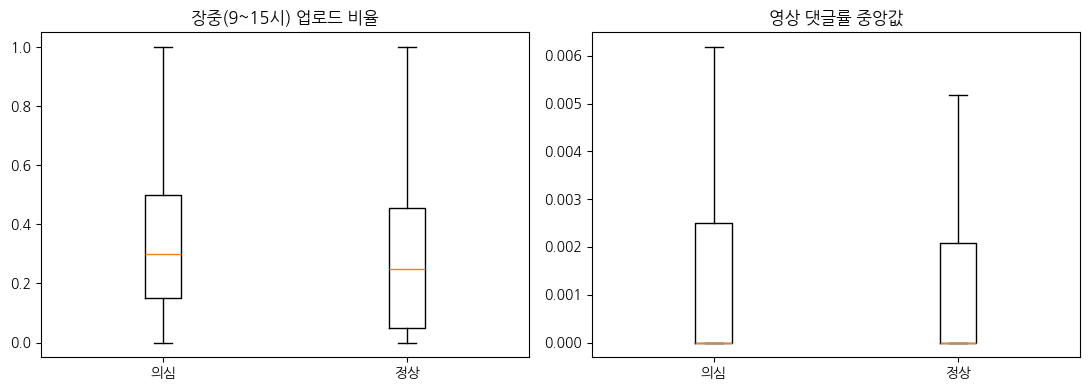

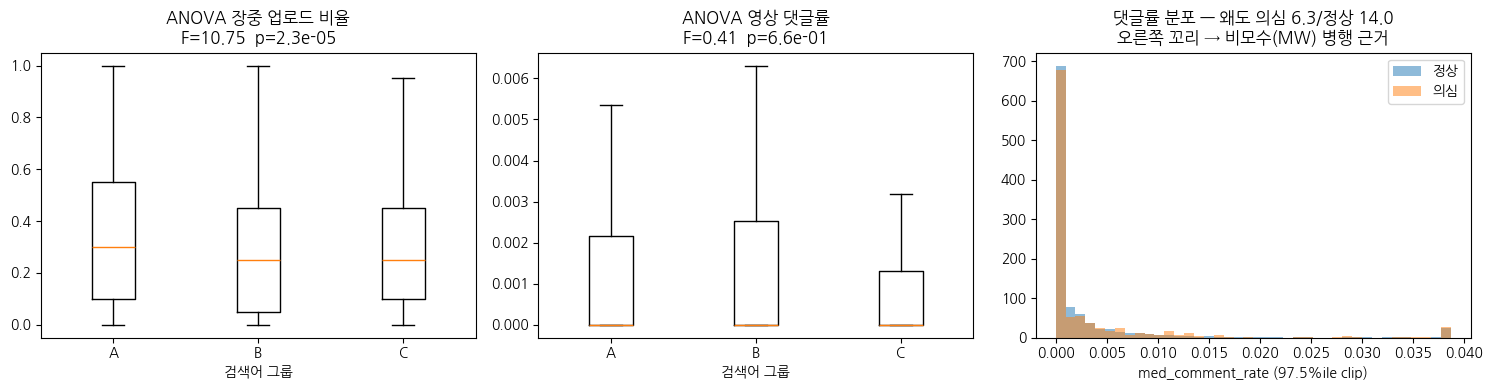

In [10]:
def mean_diff_ci(a, b):   # 두 군 평균차 95% 신뢰구간 (구간추정, 정규근사 z=1.96)
    a, b = a.dropna(), b.dropna()
    diff = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))
    return diff, diff - 1.96*se, diff + 1.96*se

sus, nor = cf[cf['seed'] == 'suspect'], cf[cf['seed'] == 'normal']
H3_VARS = ['med_comment_rate', 'market_hours_ratio', 'med_ttf_hours']

print('검정 선택 근거 — 분산비가 1에서 멀면 Welch, 왜도가 크면 비모수(MW):')
for _v in H3_VARS:
    _a, _b = sus[_v].dropna(), nor[_v].dropna()
    print(f'  {_v}: 분산비(의심/정상)={_a.var()/_b.var():.2f}  왜도 의심={_a.skew():.2f}/정상={_b.skew():.2f}')

rows = []
for v in H3_VARS:
    a, b = sus[v].dropna(), nor[v].dropna()
    diff, lo, hi = mean_diff_ci(a, b)
    rows.append({'변수': v, '의심 평균': a.mean(), '정상 평균': b.mean(), '평균차': diff,
                 '평균차 95%CI': f'[{lo:.4f}, {hi:.4f}]',
                 'welch_p': stats.ttest_ind(a, b, equal_var=False).pvalue,
                 'mw_p': stats.mannwhitneyu(a, b).pvalue})
display(pd.DataFrame(rows).round(4))

# 검색어 그룹 간 차이(ANOVA): A/B/C — search_query의 허용 용도(평가·사전 참고용)
for v in ['market_hours_ratio', 'med_comment_rate']:
    g = [cf.loc[cf['q_group'] == k, v].dropna() for k in ['A', 'B', 'C']]
    f = stats.f_oneway(*g)
    print(f'ANOVA {v} (A/B/C): F={f.statistic:.2f}  p={f.pvalue:.1e}  '
          f'그룹평균={[round(x.mean(), 4) for x in g]}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].boxplot([sus['market_hours_ratio'].dropna(), nor['market_hours_ratio'].dropna()],
              tick_labels=['의심', '정상'], showfliers=False)
ax[0].set_title('장중(9~15시) 업로드 비율')
ax[1].boxplot([sus['med_comment_rate'].dropna(), nor['med_comment_rate'].dropna()],
              tick_labels=['의심', '정상'], showfliers=False)
ax[1].set_title('영상 댓글률 중앙값')
plt.tight_layout(); plt.show()

# 검정 선택 근거 + ANOVA 시각화 (텍스트 print를 눈으로)
fig, ex = plt.subplots(1, 3, figsize=(15, 4))
for j, (v, ttl) in enumerate([('market_hours_ratio', '장중 업로드 비율'), ('med_comment_rate', '영상 댓글률')]):
    g = [cf.loc[cf['q_group'] == k, v].dropna() for k in ['A', 'B', 'C']]   # ANOVA: 검색어 그룹 A/B/C 차이를 눈으로
    ex[j].boxplot(g, tick_labels=['A', 'B', 'C'], showfliers=False)
    f = stats.f_oneway(*g)
    ex[j].set_title('ANOVA %s\nF=%.2f  p=%.1e' % (ttl, f.statistic, f.pvalue))
    ex[j].set_xlabel('검색어 그룹')
_cap = cf['med_comment_rate'].dropna().quantile(0.975)                       # 왜도(오른쪽 꼬리) → 비모수 MW 병행 근거
ex[2].hist(nor['med_comment_rate'].dropna().clip(upper=_cap), bins=40, alpha=0.5, density=True, label='정상')
ex[2].hist(sus['med_comment_rate'].dropna().clip(upper=_cap), bins=40, alpha=0.5, density=True, label='의심')
ex[2].set_title('댓글률 분포 — 왜도 의심 6.3/정상 14.0\n오른쪽 꼬리 → 비모수(MW) 병행 근거')
ex[2].set_xlabel('med_comment_rate (97.5%ile clip)'); ex[2].legend()
plt.tight_layout(); plt.show()


**H3 판정 = 부분 채택(시황민감도 한정).** 부분 채택이란, 가설이 내건 두 축(참여율·시황민감도) 중 **시황민감도만 기준을 통과하고 참여율은 떨어져** 가설의 절반만 데이터가 지지한다는 뜻이다 — 전부 맞은 것도 전부 틀린 것도 아니다.

`market_hours_ratio`는 Welch p=0.015·Mann-Whitney p<0.001로 **두 검정 모두 유의(사전 기준=양검정 일치 충족)**, 방향도 KCMI 보고(주식채널의 장중·개장 전후 집중)와 일치 — 의심군 장중 업로드 비율 34.0% vs 정상군 30.5%. 검색어 그룹 ANOVA도 A그룹이 최고(F=10.8, p<0.001). 다만 평균차는 3.5%p, 95% 신뢰구간 [0.007, 0.063]으로 0은 벗어나지만 폭이 좁고 boxplot상 두 군이 크게 겹침 → **검정은 두 방식 모두에서 일관되게 유의하나 실질 크기는 작아 단독 판별 변수로는 부족**.

참여율 `med_comment_rate`는 Welch p=0.049지만 Mann-Whitney p=0.79로 **양검정 불일치 → 기준 미충족**(치우친 분포에서 t-test만 유의한 전형적 패턴, 신뢰 안 함). `med_ttf_hours`(첫 댓글까지 시간)는 둘 다 유의하지 않음. 가설 중 참여율 부분은 기각, 시황민감도 부분만 약하게 채택.

**남는 것**: 시황민감도는 약하지만 일관된 방향 신호 → 단독 판별 변수로는 부족해도 H1 점수 모델의 보조 feature 가치는 확인(실제 feature importance 상위권). KCMI의 "지수 변동이 조회수를 끌어올림" 교란도 해석에 반영 — 수집 시점 시장 상황이 참여 지표를 흔들 수 있음.

### **6. 종합 — 채택·기각과 남는 것**

| 가설 | 사전 기준 | 결과 | 판정 |
|---|---|---|---|
| H1 분류 | recall ≥ 0.7, F1 ≥ 0.6 | recall 0.48, F1 0.52 (AUC 0.80) | **기각** |
| H2 군집 | V-measure ≥ 0.2 | V-measure 0.03 (의심이 몰린 군집 2.2배는 존재) | **기각** |
| H3 검정 | Welch·MW 모두 p<0.05 | 시황민감도 양검정 일치(평균차 3.5%p·CI 좁음), 참여율 불일치 | **부분 채택** |

세 가설 모두 깔끔히 채택되진 않았다 — H1·H2는 기각, H3는 시황민감도 한 변수만 약하게 부분 채택되었다. 하지만 이건 분석이 실패한 게 아니라 오히려 핵심 발견이다. **"규제어 없이 채널 운영 패턴 하나만 보고 리딩방을 차단/통과 두 갈래로 딱 잘라 판별할 수 있다"는 처음의 가정 자체가 데이터로 반박된 것**이기 때문이다.

1. **단일 신호로는 차단 못 한다.** 운영 패턴이든 군집 위치든 참여 통계든, 어느 하나도 채널을 막을 만큼 강하지 않았다. 그나마 두 검정이 일치한 시황민감도조차 평균차가 3.5%p로 실제 차이는 작다. → 차단은 **여러 신호를 묶어야**(규제어 + 모델 점수 + 사용자 신고 등) 정당화된다.
2. **모델의 쓸모는 '판별'이 아니라 '줄 세우기'다.** 맞고 틀리고를 가르는 이진 분류로는 약하지만(AUC 0.80), 의심 정도로 채널을 정렬하는 할 때 더 판별 가능성이 높았다. 특히 규제어를 피해 간 채널(규제어는 없는데 모델 점수만 높은 채널)을 더 잘 찾아낸다.
3. **정답 라벨 확보는 중요하다** 정답 라벨이 규제어 휴리스틱이라 정답 자체에 잡음이 섞여 있었다. 그래서 다음 단계의 1순위는 더 좋은 모델이 아니라 **정답 라벨 확보**다.

**산출물 — 두 리스트로 내보낸다.** 위 결론을 그대로 파일로 옮긴다. (i) **차단 리스트**: 규제어가 걸리고(법적 근거) 모델 점수가 차단 운영점(precision≥0.9) 이상인 채널만 — "확실한 것만 막는다". 모델 점수 단독 차단은 H1 기각 근거로 금지하므로 규제어 동반을 필수로 둔다. (ii) **의심 리스트**: 점수가 의심 운영점(precision≥0.7) 이상인 채널을 점수순으로 — 규제어가 없어도 포함(회피형 후보)하며, 차단이 아니라 수동 검토·신고 우선순위 큐로 쓴다. 둘 다 가공 데이터셋으로 저장(아래 셀).

In [11]:
# === 산출물: 차단 리스트 + 의심 리스트 (분석 결론을 두 CSV로 출력) ===
# 운영점 = cell 12 PR sweep과 동일: precision≥0.9 → 차단 / precision≥0.7 → 의심
def thr_at(p, default=0.99):                     # 해당 precision을 넘는 가장 낮은 threshold(=최대 recall). 없으면 보수적 기본값
    ok = np.where(prec >= p)[0]
    return float(thr_grid[ok[0]]) if len(ok) else default
blk_thr, sus_thr = thr_at(0.9), thr_at(0.7)

# 전 채널 모델 점수 — 학습엔 정답 라벨 있는 채널만 썼고 점수는 모든 채널에 매김(=줄세우기)
cf['rf_score'] = rf.predict_proba(cf[X_cols].fillna(med))[:, 1]

# 규제어 매칭 — 차단의 '법적 근거'(라벨 근거지 feature 아님). H는 channel_id 인덱스
mk = H[list(REG)].apply(lambda r: '·'.join(k for k in REG if r[k] > 0), axis=1)
cf['규제어종수']  = cf['channel_id'].map(H['kinds']).fillna(0).astype(int)
cf['규제어총매칭'] = cf['channel_id'].map(H['total']).fillna(0).astype(int)
cf['매칭규제어']  = cf['channel_id'].map(mk).fillna('')

out_cols = ['channel_id', 'title', 'rf_score', '규제어종수', '규제어총매칭', '매칭규제어', 'q_group']

# 차단 리스트 = 규제어 hit 그리고 점수≥차단 (H1 기각 → 모델 단독 차단 금지, 규제어 동반 필수)
block = cf[(cf['규제어총매칭'] > 0) & (cf['rf_score'] >= blk_thr)].sort_values('rf_score', ascending=False)
# 의심 리스트 = 점수≥의심 (규제어 없어도 포함 — 회피형 후보, 검토·신고 우선순위 큐)
watch = cf[cf['rf_score'] >= sus_thr].sort_values('rf_score', ascending=False)

block[out_cols].to_csv(P / '차단리스트.csv', index=False, encoding='utf-8-sig')
watch[out_cols].to_csv(P / '의심리스트.csv', index=False, encoding='utf-8-sig')

print(f'차단 threshold(precision≥0.9) = {blk_thr:.2f} | 의심 threshold(precision≥0.7) = {sus_thr:.2f}')
print(f'차단 리스트 {len(block):>4}개 → {P}/차단리스트.csv  (규제어 hit AND 점수≥{blk_thr:.2f})')
print(f'의심 리스트 {len(watch):>4}개 → {P}/의심리스트.csv  (점수≥{sus_thr:.2f}, 규제어 무관)')
print('\n차단 리스트 상위:')
display(block[out_cols].head(10))

차단 threshold(precision≥0.9) = 0.92 | 의심 threshold(precision≥0.7) = 0.77
차단 리스트   75개 → ../data/processed/차단리스트.csv  (규제어 hit AND 점수≥0.92)
의심 리스트  304개 → ../data/processed/의심리스트.csv  (점수≥0.77, 규제어 무관)

차단 리스트 상위:


,channel_id,title,rf_score,규제어종수,규제어총매칭,매칭규제어,q_group
1366,UCxNOYD9H-jzZjQbAdNCy9wQ,코스닥 심층분석,1.000000,2,7,리딩방·자동매매,B
1596,UCfr0pDyuy6a1JJLfGubSD7A,주식수익의 달인,1.000000,3,10,리딩방·종목추천·자동매매,B
1479,UCdZoTT7vo_RS8ou5pt0i5GQ,주식시선 정책리뷰,1.000000,2,3,리딩방·자동매매,B
1430,UCH0enZmLHjmX74wPTMVXyNg,투자맥락 시황브리핑,0.996667,2,4,리딩방·자동매매,B
1443,UCr1Fsm4V7EuVeHPqXAcAR3g,정책시황주식통,0.996667,2,6,리딩방·자동매매,B
620,UCKa2O4OyWs0KVQv5cn-Hzkw,주식정책,0.993333,2,9,리딩방·자동매매,A
1483,UC-4nKlO7tfm9m3Wg2jNWSeQ,🧭정책동향 주식 분석,0.993333,2,7,리딩방·자동매매,B
1417,UCgAjQ4rlGWhMjdJbnweAP5w,정책맥 주식시선,0.993333,3,7,리딩방·종목추천·자동매매,B
1444,UCnxWDI-WmuG0rgpcuUHEcSw,시황맥 주식인사이트,0.990000,3,5,리딩방·종목추천·자동매매,B
1453,UCIsxTjSK-VFVh4YHTi07kZQ,주식가치 판단가,0.990000,1,1,자동매매,B


### **7. 한계와 결론**

**한계**
1. **선택편향**: 모집단 = 30개 주식 검색어로 검색되는 채널. 경제 유튜브 전체로 일반화 불가 — 차단·의심 리스트도 이 모집단 안에서만 유효하며, 비경제 채널엔 점수 자체를 매기지 않는다.
2. **정답 라벨 noise**: 규제어 휴리스틱 라벨이지 법적 판정·전문가 검수 아님. H1~H3의 성능·효과크기 모두 이 상한에 눌림. 회색지대 362개 분리로 완화했으나 해소는 아님.
3. **시점 단면 데이터**: 수집 시점 1회 스냅샷. KCMI가 보인 시장 상황–참여 상관을 통제 못 함(시계열 수집이 후속 과제).
4. **차단의 법적 성격**: 모델 점수는 법적 판단이 아님 — 차단·의심 리스트는 "의심 정보 제공 + 신고 연계"용이며 최종 판단·제재는 금융당국(금감원 신고센터 fine.fss.or.kr) 몫.

**결론**: H1·H2는 사전 기준에서 기각, H3는 시황민감도 한정 약한 부분 채택 — 어느 쪽도 단일 신호로 차단을 정당화하진 못하며, 그 결과가 곧 설계 지침이 됨 — 리딩방 탐지는 단일 모델 문제가 아니라 **규제어(법적 근거) × 행동 점수(순위화) × 사용자 신고(라벨 축적)를 결합한 운영 시스템 문제**. 정확도가 아닌 insight: "무엇으로 차단할 수 있는가"가 아니라 "무엇만으로는 차단하면 안 되는가"를 데이터가 답함. 그 답을 6장에서 차단 리스트(규제어+고점수)·의심 리스트(점수 순위) 두 산출물로 옮김.